# Transfer Learning for Image Classification

This notebook demonstrates the application of transfer learning for image classification tasks using pre-trained convolutional neural networks (CNNs) from `tf.keras.applications`. We will explore three different classification problems:

1.  **CIFAR-10 Classification with ResNet-50**
2.  **CIFAR-100 Classification with MobileNetV2**
3.  **Cats vs. Dogs Classification with InceptionV3**

For each task, we will load a pre-trained model, freeze its layers (or a portion of them), and add custom classification layers to adapt it to the specific dataset. The models will then be trained and evaluated to demonstrate the effectiveness of transfer learning.

## CIFAR-10 Classification with ResNet-50

In this task, we will use a pre-trained ResNet-50 model, initially trained on ImageNet, and adapt it to classify images from the CIFAR-10 dataset. The ResNet-50 layers will be frozen, and new dense layers will be added on top for classification.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.1969 - loss: 2.1807 - val_accuracy: 0.2796 - val_loss: 1.9457
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.3092 - loss: 1.8987 - val_accuracy: 0.3190 - val_loss: 1.8905
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.3306 - loss: 1.8379 - val_accuracy: 0.3466 - val_loss: 1.8362
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3464 - loss: 1.7897 - val_accuracy: 0.3631 - val_loss: 1.7590
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.3600 - loss: 1.7708 - val_accuracy: 0.3656 - val_loss: 1.7598
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3694 - loss: 1.7509 - val_accuracy: 0.3572 - val_loss: 1.7784
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.3775 - loss: 1.7384 - val_accuracy: 0.

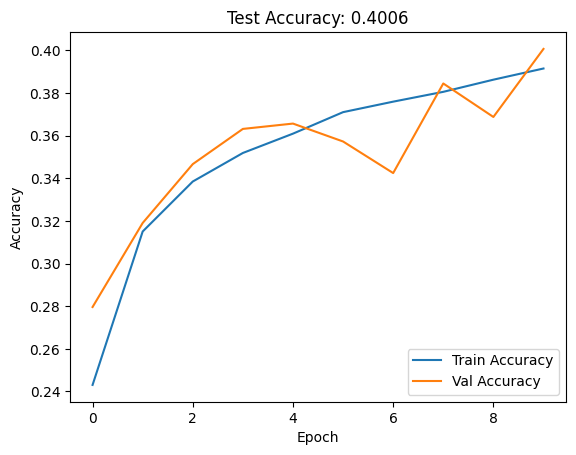

Test Accuracy: 0.40059998631477356


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Load the ResNet-50 model, pretrained on ImageNet, with include_top=False
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze all layers in ResNet-50
for layer in resnet.layers:
    layer.trainable = False

# Add custom classification layers for CIFAR-10
model = models.Sequential([
    resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model for 10 epochs
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title(f'Test Accuracy: {test_acc:.4f}')
plt.show()

print(f'Test Accuracy: {test_acc}')


CIFAR-100 Classification with MobileNetV2

This task focuses on classifying images from the CIFAR-100 dataset using a pre-trained MobileNetV2 model. Similar to Task 1, the MobileNetV2 layers will be frozen, and custom classification layers will be added and trained for this specific dataset.

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


<ipython-input-2-590b9bc2eb32>:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.0658 - loss: 4.2648 - val_accuracy: 0.1168 - val_loss: 3.8970
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1248 - loss: 3.8255 - val_accuracy: 0.1291 - val_loss: 3.8147
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1440 - loss: 3.7004 - val_accuracy: 0.1320 - val_loss: 3.7712
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1555 - loss: 3.6228 - val_accuracy: 0.1393 - val_loss: 3.7426
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1645 - loss: 3.5577 - val_accuracy: 0.1412 - val_loss: 3.7316
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1759 - loss: 3.5030 - val_accuracy: 0.1435 - val_loss: 3.7298
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1856 - loss: 3.4477 - val_accuracy: 0.1451 - val_loss: 3.7310
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━

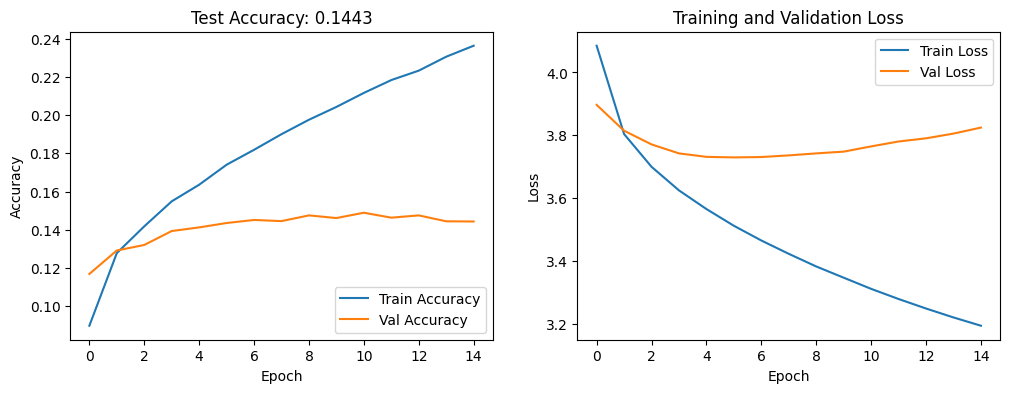

Test Accuracy: 0.14429999887943268


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# 1. Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# 2. Preprocess the dataset by normalizing pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

# 3. Load the MobileNetV2 model, pretrained on ImageNet, with include_top=False
mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 5. Freeze all MobileNetV2 layers
for layer in mobilenet.layers:
    layer.trainable = False

# 4. Add custom layers for CIFAR-100 classification
model = models.Sequential([
    mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(100, activation='softmax')
])

# 6. Compile the model with categorical cross-entropy loss and Adam optimizer
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 7. Train the model on CIFAR-100 for 15 epochs
history = model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))

# 8. Evaluate the model on the test set and report the final test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)

# 8. Visualize training/validation accuracy and loss curves
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title(f'Test Accuracy: {test_acc:.4f}')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

print(f'Test Accuracy: {test_acc}')


## Cats vs. Dogs Classification with InceptionV3

In this final task, we will tackle a binary classification problem: distinguishing between cats and dogs. We will utilize a pre-trained InceptionV3 model, fine-tuning some of its later layers, and adding custom dense layers for the binary classification task.

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/23262 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.B9E8Z8_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 144s 208ms/step - accuracy: 0.9034 - loss: 0.3072 - val_accuracy: 0.9905 - val_loss: 0.0480
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.9898 - loss: 0.0441 - val_accuracy: 0.9927 - val_loss: 0.0289
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.9914 - loss: 0.0295 - val_accuracy: 0.9931 - val_loss: 0.0232
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 141ms/step - accuracy: 0.9929 - loss: 0.0243 - val_accuracy: 0.9936 - val_loss: 0.0207
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.9938 - loss: 0.0215 - val_accuracy: 0.9944 - val_loss: 0.0193
146/146 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.9961 - loss: 0.0166
Test accuracy: 0.9944


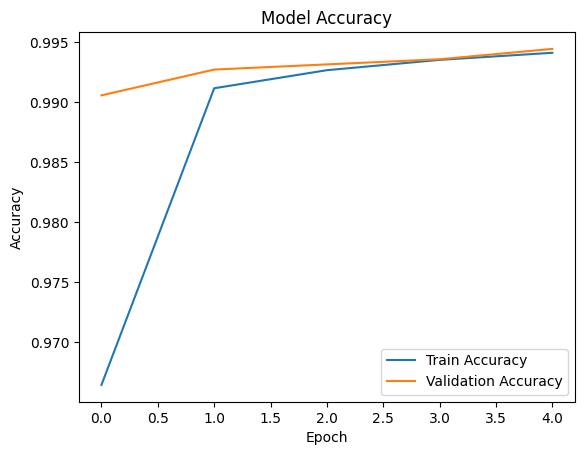

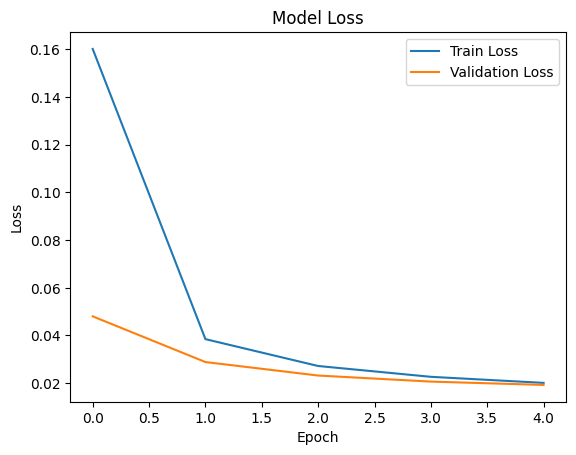

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
import matplotlib.pyplot as plt

# Load the Cats vs. Dogs dataset
dataset, metadata = tfds.load('cats_vs_dogs', split=['train[:80%]', 'train[80%:]'], with_info=True, as_supervised=True)

# Split the dataset into training and validation sets
train_dataset, validation_dataset = dataset

# Preprocessing function to resize images and normalize pixel values
def preprocess_image(image, label):
    image = tf.image.resize(image, [299, 299])  # Resize images to 299x299
    image = image / 255.0  # Normalize pixel values to [0, 1]
    return image, label

# Apply the preprocessing
train_dataset = train_dataset.map(preprocess_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
validation_dataset = validation_dataset.map(preprocess_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

# Load InceptionV3 model without the top layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze all layers except the last 4 convolutional layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# custom classification layers
model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])
# Compile the model with a low learning rate for fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])
# Fine-tune the model by training it on the Cats vs. Dogs dataset for 20 epochs
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)
test_loss, test_accuracy = model.evaluate(validation_dataset)
print(f'Test accuracy: {test_accuracy:.4f}')

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()